<div style="background: linear-gradient(135deg, #000000, #0f9b0f); 
padding: 20px; 
border-radius: 14px; 
color: #FFFFFF; 
font-size: 40px; 
font-family: 'Orbitron', sans-serif; 
text-align: center; 
box-shadow: 0 0 25px rgba(0,255,102,0.7);
text-shadow: 0 0 10px rgba(0,255,102,1);
text-transform: uppercase;">
<b>🍃 Otimizador de Plantio Sustentável</b>
</div>

## Descrição
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

Projeto voltado para a agricultura de precisão que identifica o nível de hidratação ou deficiência através de análise quantitativa ou qualitativa de nutrientes  específicos apenas pela análise da textura e coloração das folhas 

### Objetivo  
Ir além da simples "doença ou saúde". O modelo tentaria prever quanto de determinado nutriente falta, focando em estresses abióticos (falta de nitrogênio, fósforo, potássio ou água) ajudando a reduzir o desperdício de fertilizantes.  

### Dataset
PlantVillage Dataset. Disponível em:     
https://www.kaggle.com/datasets/emmarex/plantdisease?resource=download  

### Biblioteca e Configurações Globais
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

In [58]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Configurações globais
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 15

# Armazenamento do dataset
dataset = r"C:\Users\kenny\OneDrive\Documentos\UFPB\P9\Aprendizado Profundo\projetofinaldl\PlantVillage"


## Data Argumentation
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

In [47]:
# Pipeline dos Dados
# Normalização e Aumento de Dados (20% para teste)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 
)

# Carregamento automático das pastas
train_generator = train_datagen.flow_from_directory(
    dataset.repeat(), 
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset.,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 33027 images belonging to 16 classes.
Found 8249 images belonging to 16 classes.


## Arquitetura do Modelo (Transfer Learning - MobileNetV2)
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

In [50]:
# Base pré-treinada
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Congelamos o conhecimento prévio

# Camada personalizada de saída
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Evita que o modelo decore os dados (overfitting)
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │          20,496 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,278,480 (8.69 MB)

 Trainable params: 20,496 (80.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Treinamento e Monitoramento
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

# Salvar o modelo para uso futuro
model.save('modelo_nutricao_plantas.h5')

Epoch 1/15
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1273s 1s/step - accuracy: 0.5401 - loss: 1.0740 - val_accuracy: 0.2480 - val_loss: 2.8758
Epoch 2/15
 319/1033 ━━━━━━━━━━━━━━━━━━━━ 13:48 1s/step - accuracy: 0.5507 - loss: 1.0529

## Resultados
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

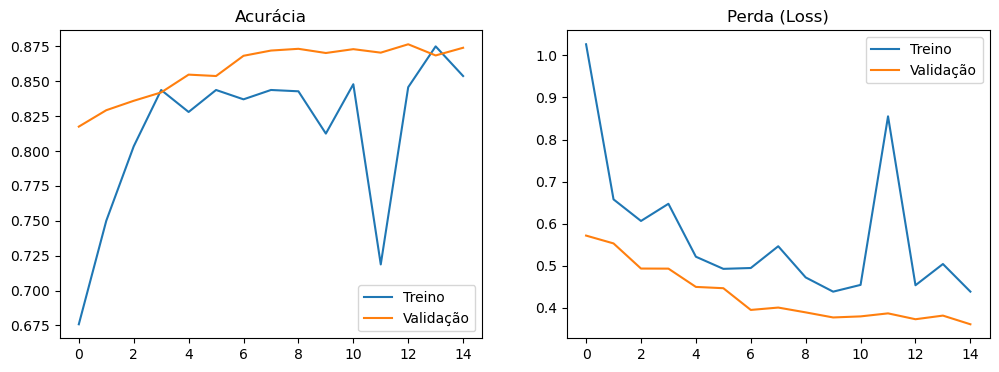

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino')
plt.plot(epochs_range, val_acc, label='Validação')
plt.title('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino')
plt.plot(epochs_range, val_loss, label='Validação')
plt.title('Perda (Loss)')
plt.legend()
plt.show()

## Loss e Accuracy de Teste
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

In [17]:
# Avaliação final no conjunto de validação/teste
test_loss, test_acc = model.evaluate(validation_generator, verbose=2)
print(f'\nAcurácia no Teste: {test_acc*100:.2f}%')


126/126 - 113s - 895ms/step - accuracy: 0.8798 - loss: 0.3632

Acurácia no Teste: 87.98%


## Matriz de Confusão
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

126/126 ━━━━━━━━━━━━━━━━━━━━ 110s 847ms/step


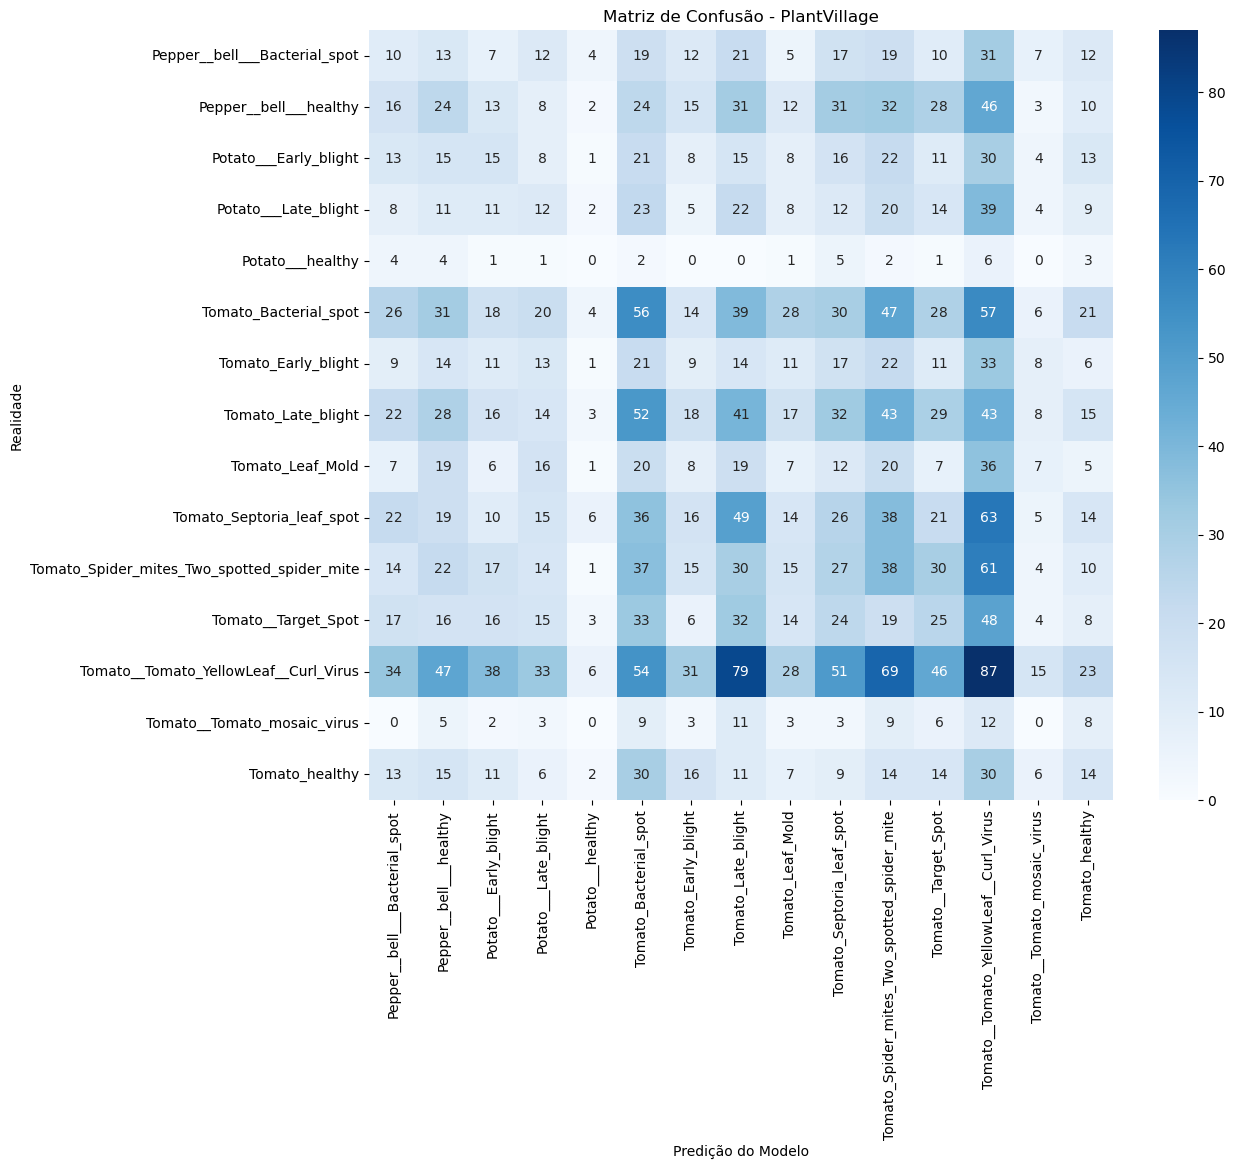

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.05      0.05      0.05       199
                     Pepper__bell___healthy       0.08      0.08      0.08       295
                      Potato___Early_blight       0.08      0.07      0.08       200
                       Potato___Late_blight       0.06      0.06      0.06       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.13      0.13      0.13       425
                        Tomato_Early_blight       0.05      0.04      0.05       200
                         Tomato_Late_blight       0.10      0.11      0.10       381
                           Tomato_Leaf_Mold       0.04      0.04      0.04       190
                  Tomato_Septoria_leaf_spot       0.08      0.07      0.08       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.09      0.11

In [19]:
# Obter as predições ( Resetamos o generator para garantir a ordem correta)
validation_generator.reset()
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Rótulos 
y_true = validation_generator.classes
class_names = list(validation_generator.class_indices.keys())

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - PlantVillage')
plt.ylabel('Realidade')
plt.xlabel('Predição do Modelo')
plt.show()

# Relatório detalhado (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

## Visualizando as Predições
<span style="background:#affad1"><hr style="border: 2px solid green;"></span>

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


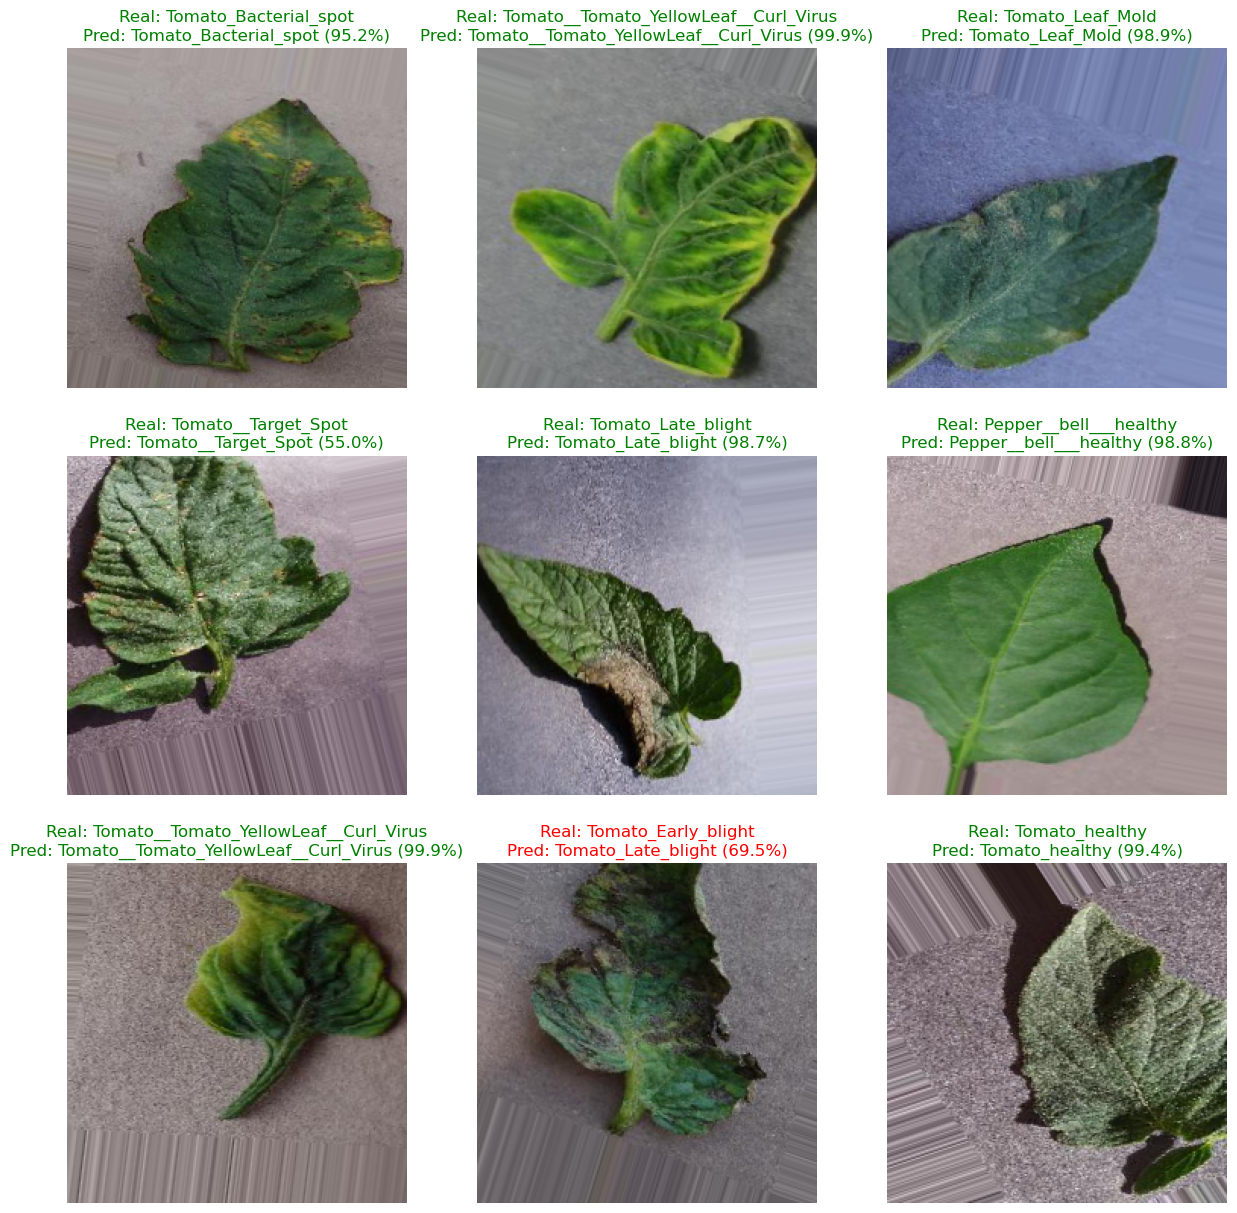

In [21]:
def plot_prediction(model, generator):
    # Pega um batch de imagens
    x_test, y_test = next(generator)
    preds = model.predict(x_test)
    
    plt.figure(figsize=(15, 15))
    for i in range(9): # Mostra as primeiras 9 imagens do batch
        plt.subplot(3, 3, i+1)
        plt.imshow(x_test[i])
        
        actual_label = class_names[np.argmax(y_test[i])]
        pred_label = class_names[np.argmax(preds[i])]
        confidence = np.max(preds[i]) * 100
        
        color = 'green' if actual_label == pred_label else 'red'
        plt.title(f"Real: {actual_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color)
        plt.axis('off')
    plt.show()

plot_prediction(model, validation_generator)